# Data Profiling: Chlorophyll-a Concentration (Sarasota, Dataset 1)

`ChlorophyllaConcentrationSarasota.csv` — NOAA CoastWatch satellite-derived, gap-filled chlorophyll-a concentration, gridded over the Sarasota-area waters (2020-2026).

**Goal:** Apply the same profiling approach used for `florida_cyanotoxins` and `habsos_cellcounts` (row counts, column types, missing values, duplicates, invalid values, outliers) to this dataset.

**Note:** A second chlorophyll-a file, `ChlorophyllaConcentrationSarasota_Dataset2.csv`, is profiled separately in [data_profiling_chlorophyll_dataset2.ipynb](./data_profiling_chlorophyll_dataset2.ipynb).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = "../data"
CHLOROPHYLL_PATH = f"{DATA_DIR}/ChlorophyllaConcentrationSarasota.csv"

# ERDDAP export: row 0 is the header, row 1 is a units row, data starts at row 2.
UNITS_ROW = [1]

In [2]:
def profile_dataset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Return a per-column profile: dtype, inferred kind, missingness, uniqueness."""
    n_rows = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        n_missing = s.isna().sum()
        n_unique = s.nunique(dropna=True)
        if pd.api.types.is_numeric_dtype(s):
            kind = "numeric"
        elif pd.api.types.is_bool_dtype(s):
            kind = "boolean"
        else:
            kind = "categorical/text"
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "kind": kind,
            "n_missing": n_missing,
            "pct_missing": round(100 * n_missing / n_rows, 2) if n_rows else 0,
            "n_unique": n_unique,
            "sample_values": list(s.dropna().unique()[:3]),
        })
    profile = pd.DataFrame(rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
    print(f"[{name}] shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"[{name}] exact duplicate rows: {df.duplicated().sum():,}")
    return profile


def lon_360_to_180(lon: pd.Series) -> pd.Series:
    """ERDDAP grids often use 0-360 longitude convention; convert to standard -180..180."""
    return ((lon + 180) % 360) - 180

## 1. Load and high-level overview

In [3]:
chl = pd.read_csv(CHLOROPHYLL_PATH, skiprows=UNITS_ROW, low_memory=False)
chl.head()

,time,altitude,latitude,longitude,chlor_a
0,2020-06-15T12:00:00Z,0.0,27.99375,276.50625,NaN
1,2020-06-15T12:00:00Z,0.0,27.99375,276.54375,NaN
2,2020-06-15T12:00:00Z,0.0,27.99375,276.58125,NaN
3,2020-06-15T12:00:00Z,0.0,27.99375,276.61875,NaN
4,2020-06-15T12:00:00Z,0.0,27.99375,276.65625,NaN


In [4]:
chl_profile = profile_dataset(chl, "ChlorophyllaConcentrationSarasota")
chl_profile

[ChlorophyllaConcentrationSarasota] shape: 4,202,008 rows x 5 columns


[ChlorophyllaConcentrationSarasota] exact duplicate rows: 0


,column,dtype,kind,n_missing,pct_missing,n_unique,sample_values
0,chlor_a,float64,numeric,3162496,75.26,1028932,"[0.16371904, 0.16246322, 0.19935663]"
1,time,str,categorical/text,0,0.00,2228,"[2020-06-15T12:00:00Z, 2020-06-16T12:00:00Z, 2..."
2,altitude,float64,numeric,0,0.00,1,[0.0]
3,latitude,float64,numeric,0,0.00,41,"[27.99375, 27.95625, 27.91875]"
4,longitude,float64,numeric,0,0.00,46,"[276.50625, 276.54375, 276.58125]"


## 2. Numeric vs. categorical columns

In [5]:
chl_numeric_cols = chl_profile.loc[chl_profile["kind"] == "numeric", "column"].tolist()
chl_categorical_cols = chl_profile.loc[chl_profile["kind"] != "numeric", "column"].tolist()
print(f"Numeric columns ({len(chl_numeric_cols)}): {chl_numeric_cols}")
print(f"Categorical/text columns ({len(chl_categorical_cols)}): {chl_categorical_cols}")

print("\naltitude unique values:", chl["altitude"].unique(), "-> constant column, carries no information")

Numeric columns (4): ['chlor_a', 'altitude', 'latitude', 'longitude']
Categorical/text columns (1): ['time']

altitude unique values: [0.] -> constant column, carries no information


## 3. Missing values

Satellite chlorophyll-a is derived from ocean-color sensors that can't see through cloud cover, so a large fraction of grid cell/time combinations are expected to be missing (`NaN`) by nature of the data source, not a data-quality defect.

In [6]:
print("Missing values:\n", chl.isna().sum())
print(f"\npct chlor_a missing: {100 * chl['chlor_a'].isna().mean():.1f}%")
print("(expected: satellite chlorophyll-a is unavailable under cloud cover / no valid retrieval)")

Missing values:
 time               0
altitude           0
latitude           0
longitude          0
chlor_a      3162496
dtype: int64

pct chlor_a missing: 75.3%
(expected: satellite chlorophyll-a is unavailable under cloud cover / no valid retrieval)


## 4. Duplicates

In [7]:
print("Exact duplicate rows:", chl.duplicated().sum())

n_grid_points = chl[["latitude", "longitude"]].drop_duplicates().shape[0]
n_timestamps = chl["time"].nunique()
print(f"\nUnique (lat, lon) grid points: {n_grid_points:,}")
print(f"Unique timestamps: {n_timestamps:,}")
print(f"grid_points x timestamps = {n_grid_points * n_timestamps:,} vs. actual rows = {len(chl):,}")

Exact duplicate rows: 0



Unique (lat, lon) grid points: 1,886
Unique timestamps: 2,228
grid_points x timestamps = 4,202,008 vs. actual rows = 4,202,008


## 5. Invalid values

In [8]:
chl["time_parsed"] = pd.to_datetime(chl["time"], errors="coerce")
print("Parsed date range:", chl["time_parsed"].min(), "to", chl["time_parsed"].max())
print("Rows where date failed to parse:", chl["time_parsed"].isna().sum())

print("\nRaw latitude range:", chl["latitude"].min(), "to", chl["latitude"].max())
print("Raw longitude range:", chl["longitude"].min(), "to", chl["longitude"].max())
chl["longitude_180"] = lon_360_to_180(chl["longitude"])
print("Converted longitude range:", chl["longitude_180"].min(), "to", chl["longitude_180"].max())

print("\nNegative chlor_a values:", (chl["chlor_a"] < 0).sum())
print("chlor_a == 0 exactly:", (chl["chlor_a"] == 0).sum())
print("chlor_a stats:\n", chl["chlor_a"].describe())

Parsed date range: 2020-06-15 12:00:00+00:00 to 2026-09-05 12:00:00+00:00
Rows where date failed to parse: 0

Raw latitude range: 26.49375 to 27.99375
Raw longitude range: 276.50625 to 278.19375


Converted longitude range: -83.49374999999998 to -81.80624999999998

Negative chlor_a values: 0
chlor_a == 0 exactly: 0


chlor_a stats:
 count    1.039512e+06
mean     2.277557e+00
std      4.971443e+00
min      1.000000e-03
25%      2.562752e-01
50%      5.677464e-01
75%      2.074664e+00
max      9.999950e+01
Name: chlor_a, dtype: float64


## 6. Outliers

`chlor_a` ranges from ~0.001 to ~100 mg/m^3 with a median around 0.57, so outliers are assessed on a log scale rather than raw IQR (a raw-scale boxplot would collapse to a sliver near zero).

IQR upper bound (log1p scale): 2.47 -> raw mg/m^3: 10.77
Rows above upper bound: 45866 (4.41% of non-missing rows)
Max observed value: 100.00 mg/m^3


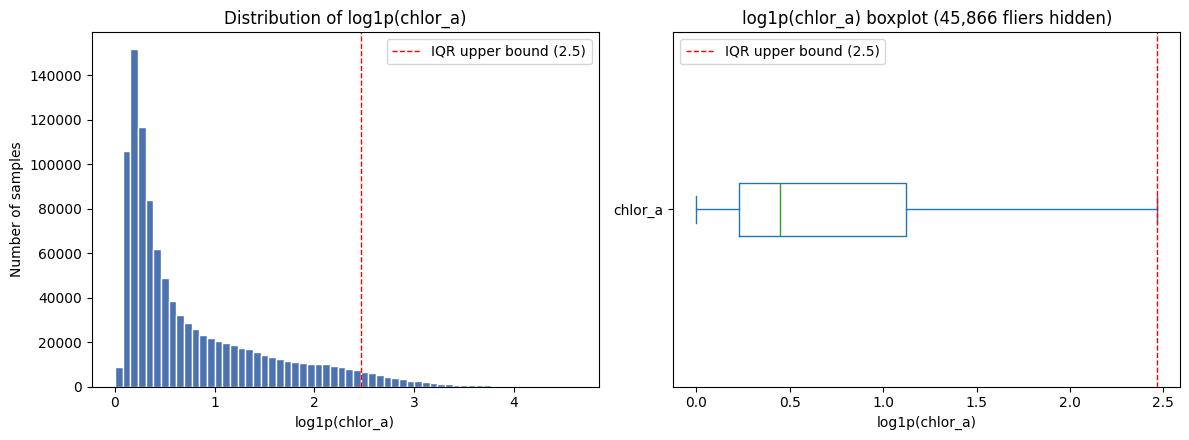

In [9]:
valid_chl = chl["chlor_a"].dropna()
log_chl = np.log1p(valid_chl)
q1, q3 = log_chl.quantile(0.25), log_chl.quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_outliers = int((log_chl > upper).sum())
print(f"IQR upper bound (log1p scale): {upper:.2f} -> raw mg/m^3: {np.expm1(upper):.2f}")
print(f"Rows above upper bound: {n_outliers} ({100 * n_outliers / len(valid_chl):.2f}% of non-missing rows)")
print(f"Max observed value: {valid_chl.max():.2f} mg/m^3")

# Fliers are hidden (showfliers=False): with this many points beyond the IQR bound, plotting each
# as a marker overplots into a solid smear rather than a readable boxplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(log_chl, bins=60, color="#4C72B0", edgecolor="white")
axes[0].axvline(upper, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound ({upper:.1f})")
axes[0].set_xlabel("log1p(chlor_a)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Distribution of log1p(chlor_a)")
axes[0].legend()

log_chl.plot(kind="box", vert=False, ax=axes[1], showfliers=False)
axes[1].axvline(upper, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound ({upper:.1f})")
axes[1].set_xlabel("log1p(chlor_a)")
axes[1].set_title(f"log1p(chlor_a) boxplot ({n_outliers:,} fliers hidden)")
axes[1].legend()
plt.tight_layout()
plt.show()